In [2]:
import pandas as pd
import numpy as np

# 1. Load the CSV files
perf  = pd.read_csv("fact_loan_performance.csv")
apps  = pd.read_csv("fact_loan_applications.csv").drop_duplicates("application_id")
cust  = pd.read_csv("dim_customer_profiles.csv")
bur   = pd.read_csv("dim_credit_bureau_data.csv")

# 2. Merge into a single master dataframe (The Star Schema Join)
df = (perf
      .merge(apps,  on=["application_id", "customer_id"], how="left")
      .merge(cust,  on="customer_id",  how="left")
      .merge(bur,   on="customer_id",  how="left"))

# 3. Verify it worked
print(f"Master Dataset Shape: {df.shape}")
df.head()

Master Dataset Shape: (8167, 37)


,loan_id,application_id,customer_id,disbursement_date,loan_amount,current_loan_status,total_principal_paid,total_interest_paid,remaining_balance,last_payment_date,...,city,state,join_date,credit_score_fico,total_credit_lines,open_credit_lines,derogatory_public_records,revolving_utilization_rate,credit_history_length_months,inquiries_last_6_months
0,LOAN0000001,APP0000001,CUST004596,2025-06-23,20016.84,Charged-Off,2094.44,182.29,17922.40,2025-08-21,...,Baltimore,MD,26/01/2017,736.0,7.0,5.0,0.0,8.90,99.0,1.0
1,LOAN0000002,APP0000002,CUST004836,2025-01-27,3421.42,Charged-Off,1991.08,276.80,1430.34,2026-01-05,...,Atlanta,GA,2020-04-15,669.0,4.0,3.0,0.0,26.22,282.0,4.0
2,LOAN0000003,APP0000004,CUST003380,2025-08-15,8672.94,Fully Paid,7970.78,415.62,702.16,2027-01-15,...,Portland,OR,2016-02-12,626.0,16.0,9.0,0.0,55.49,112.0,0.0
3,LOAN0000004,APP0000005,CUST003085,2022-07-19,23926.61,In Grace Period,16015.02,1189.31,7911.59,2024-04-01,...,Indianapolis,IN,2015-04-07,717.0,2.0,4.0,0.0,18.69,331.0,1.0
4,LOAN0000005,APP0000007,CUST000951,2025-07-23,10154.68,Current,7649.64,940.00,2505.04,09/09/2026,...,Arlington,TX,2020-01-08,753.0,6.0,3.0,0.0,29.15,24.0,1.0


In [3]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# 1. Standardize date formats
for col in ["application_date", "last_payment_date", "disbursement_date"]:
    df[col] = pd.to_datetime(df[col], dayfirst=False, errors="coerce")

# 2. Fix inconsistent text casing in categories
df["employment_status"] = df["employment_status"].str.strip().str.title()
df["housing_status"]    = df["housing_status"].str.strip().str.title()

# 3. Clean up numerical anomalies
df["credit_score_fico"] = df["credit_score_fico"].replace([0, 999], np.nan) # Remove junk sentinel scores
df["revolving_utilization_rate"] = df["revolving_utilization_rate"].clip(0, 100) # Cap over-drafted cards
df["age"] = df["age"].where(df["age"].between(18, 100), np.nan) # Erase impossible ages (5, 115)

# 4. Handle Missing Values (Imputation)
num_cols = ["annual_income", "dti_ratio", "credit_score_fico", "revolving_utilization_rate"]
cat_cols = ["employment_status", "housing_status", "loan_purpose"]

# Fill numeric missing values with the median
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Fill categorical missing values with the most frequent value (mode) and encode to numbers
for c in cat_cols:
    df[c].fillna(df[c].mode()[0], inplace=True)
    df[c] = LabelEncoder().fit_transform(df[c])

print("Data successfully cleaned! Missing values remaining:", df[num_cols + cat_cols].isnull().sum().sum())

Data successfully cleaned! Missing values remaining: 0


C:\Users\sonak\AppData\Local\Temp\ipykernel_8332\815565391.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].fillna(df[c].mode()[0], inplace=True)
C:\Users\sonak\AppData\Local\Temp\ipykernel_8332\815565391.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

In [6]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. FRESH LOAD
perf  = pd.read_csv("fact_loan_performance.csv")
apps  = pd.read_csv("fact_loan_applications.csv").drop_duplicates("application_id")
cust  = pd.read_csv("dim_customer_profiles.csv")
bur   = pd.read_csv("dim_credit_bureau_data.csv")
repay = pd.read_csv("fact_repayment_history.csv")

# 2. MERGE TABLES
df = (perf
      .merge(apps,  on=["application_id", "customer_id"], how="left")
      .merge(cust,  on="customer_id",  how="left")
      .merge(bur,   on="customer_id",  how="left"))

# 3. FEATURE ENGINEERING (NSF COUNT)
nsf_counts = repay.groupby('loan_id')['payment_status'].apply(lambda x: (x == 'Bounced/NSF').sum()).reset_index(name='nsf_count')
df = df.merge(nsf_counts, on='loan_id', how='left').fillna({'nsf_count': 0})

# 4. DATA CLEANING & STANDARDIZATION
for col in ["application_date", "last_payment_date", "disbursement_date"]:
    df[col] = pd.to_datetime(df[col], dayfirst=False, errors="coerce")

df["employment_status"] = df["employment_status"].astype(str).str.strip().str.title()
df["housing_status"]    = df["housing_status"].astype(str).str.strip().str.title()

df["credit_score_fico"] = df["credit_score_fico"].replace([0, 999], np.nan)
df["revolving_utilization_rate"] = df["revolving_utilization_rate"].clip(0, 100)
df["age"] = df["age"].where(df["age"].between(18, 100), np.nan)

# 5. DEFINE FEATURES AND TARGET
FEATURES = ["credit_score_fico", "dti_ratio", "revolving_utilization_rate",
            "annual_income", "inquiries_last_6_months", "derogatory_public_records",
            "loan_amount", "term_months", "employment_status", "housing_status", "loan_purpose", "nsf_count"]
TARGET = "default_flag"

X = df[FEATURES].copy()
y = df[TARGET].copy()

# 6. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 7. IMPUTATION & ENCODING
num_cols = ["annual_income", "dti_ratio", "credit_score_fico", "revolving_utilization_rate", "nsf_count", "inquiries_last_6_months", "derogatory_public_records", "loan_amount", "term_months"]
cat_cols = ["employment_status", "housing_status", "loan_purpose"]

# Numeric Imputation
num_imputer = SimpleImputer(strategy="median")
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

# Categorical Imputation & Label Encoding
for c in cat_cols:
    X_train[c] = X_train[c].fillna(X_train[c].mode()[0])
    X_test[c] = X_test[c].fillna(X_train[c].mode()[0])
    
    le = LabelEncoder()
    X_train[c] = le.fit_transform(X_train[c])
    X_test[c] = le.transform(X_test[c])

# 8. APPLY SMOTE
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print(f"Original training target distribution: {np.bincount(y_train)}")
print(f"Resampled training target distribution (SMOTE): {np.bincount(y_resampled)}")

Original training target distribution: [6108  425]
Resampled training target distribution (SMOTE): [6108 6108]


In [10]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report

# 1. Initialize the XGBoost Classifier with early_stopping_rounds inside here
model = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=5, 
    learning_rate=0.05,
    subsample=0.8, 
    colsample_bytree=0.8,
    eval_metric="auc", 
    early_stopping_rounds=20, # Moved here
    random_state=42
)

# 2. Train the model using the SMOTE-balanced training data
model.fit(
    X_resampled, y_resampled,
    eval_set=[(X_test, y_test)], 
    verbose=False
)

# 3. Predict probabilities on the untouched Test Set
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

# 4. Print Evaluation Metrics
print(f"--- MODEL PERFORMANCE ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")
print(f"--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

--- MODEL PERFORMANCE ---
ROC-AUC Score: 1.0000

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1528
           1       1.00      0.98      0.99       106

    accuracy                           1.00      1634
   macro avg       1.00      0.99      0.99      1634
weighted avg       1.00      1.00      1.00      1634



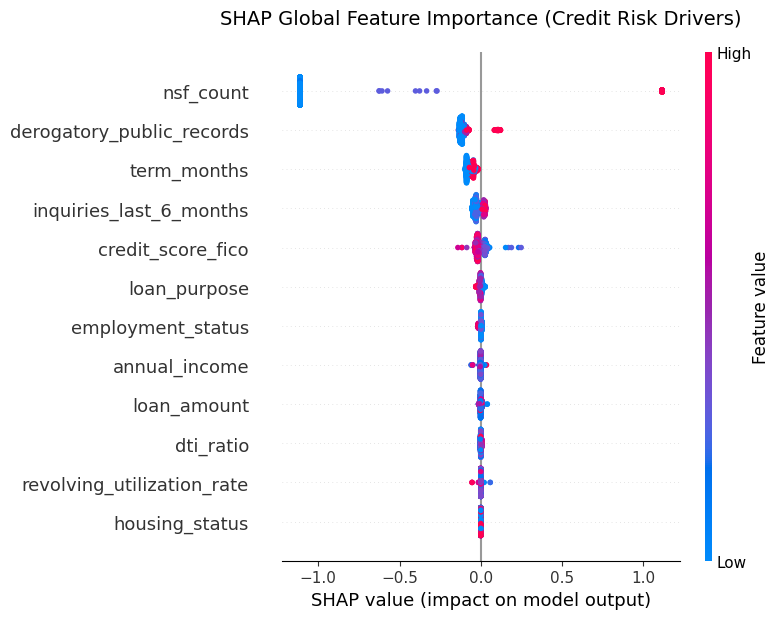

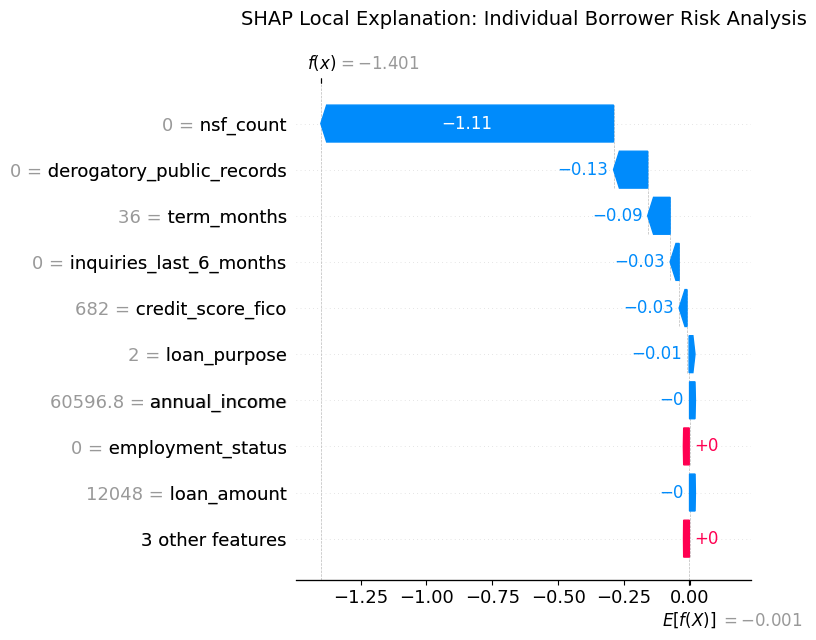

In [12]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 2. Plot Global Feature Importance (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title("SHAP Global Feature Importance (Credit Risk Drivers)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# 3. Plot a single local prediction breakdown (Waterfall Plot for row 0)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(explainer(X_test)[0], show=False)
plt.title("SHAP Local Explanation: Individual Borrower Risk Analysis", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [13]:
df.to_csv("master_credit_risk_clean.csv", index=False)
print("CSV successfully exported for MySQL!")

CSV successfully exported for MySQL!
